# Carbon Policy Scenarios — macroabm-ca (Provincial)

This notebook runs the macroeconomic ABM under two policy scenarios for all 10 Canadian provinces simultaneously, then plots provincial GDP and emissions. It is designed to let you compare how different price-setting rules affect economic and emissions outcomes across provinces.

## What this notebook does

The model simulates a multi-sector economy calibrated from a 2014 provincial input-output table for Canada. Each province has 43 industry sectors and one representative firm per sector. Households, banks, and a government are also present in each province.

Two scenarios are compared:

| # | Scenario | Price setter | What changes |
|---|----------|-------------|--------------|
| 01 | Baseline | `DefaultPriceSetter` | Firms set prices endogenously based on costs and market conditions |
| 02 | Exogenous pricing | `SectorExogenousPriceSetter` | Prices are fixed externally (e.g. to simulate a price shock or regulated market) |

## How to run

Run the cells **top to bottom, in order**. Section 5 generates the data pickle — **it only needs to run once** and takes several minutes. On subsequent runs you can skip that cell (it is commented out by default).

## Output

Per-province GDP and emissions time series, saved as PNG plots in `output/`.

**Key differences from the national version:**
- Uses the provincial IO table `icio_2014_can_provinces.csv`
- Each province gets its own `CountryConfiguration` in the simulation
- Result arrays have an extra province dimension: `(n_trials, timesteps, n_provinces, …)`

## 1 — Autoreload

In [72]:
%load_ext autoreload
%autoreload all

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2 — Paths

`INPUT_PATH` points to the raw data directory containing the OECD ICIO tables, WIOD socioeconomic accounts, and other source files. This must exist and contain the required raw files.

`PKL_PATH` is where the processed `DataWrapper` object is saved. After running Section 5 once, this file is reused by all subsequent runs to avoid reprocessing the raw data.

In [ ]:
from pathlib import Path

# place the path to the raw data directory here
INPUT_PATH = Path(r"Place your path to raw data here") / "raw_data"
BASE_DIR = Path.cwd()
OUTPUT_DIRECTORY = BASE_DIR / "output"
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
PKL_PATH = OUTPUT_DIRECTORY / "data_provincial.pkl"

print(f"Input path : {INPUT_PATH}  exists={INPUT_PATH.exists()}")
print(f"Output dir : {OUTPUT_DIRECTORY}")

Input path : C:\Users\reeti\Documents\UVic\macro-main-1\raw_data  exists=True
Output dir : c:\Users\reeti\Documents\UVic\macroabm-ca-1\output


## 3 — Imports

In [74]:
import pickle as pkl

import macromodel
import macro_data
from macro_data import DataWrapper, configuration_utils
from macro_data.configuration.countries import Country as CountryCode
from macro_data.configuration.region import Region

## 4 — Provincial data configuration

This section builds the data configuration that tells the model how to read and structure the raw input data.

The `DataWrapper` is built from a hierarchy of configuration objects. We start from `default_data_configuration` (which handles most countries automatically) and then override the Canada-specific settings to use the provincial IO table instead of the national one.

The `aggregation_structure` is the key setting: `{CAN: [CAN_AB, CAN_BC, ..., CAN_SK]}` tells the data reader to replace the single Canada entry with 10 separate provincial economies, each using a column from the provincial IO table.

| Setting | Value | Meaning |
|---------|-------|---------|
| `base` | `default_data_configuration(CAN, use_disagg_can_2014_reader=True)` | Start from a valid full config |
| `can_disaggregation` | `False` | Disable the national disaggregated reader — provinces override it |
| `aggregation_structure` | `{CAN: [10 provinces]}` | Activates the provincial IO reader |
| `scale` | `1000` | Monetary units are in millions CAD (divided by 1000 for model units) |

In [75]:
PROVINCE_INFO = {
    "CAN_AB": "Alberta",
    "CAN_BC": "British Columbia",
    "CAN_MB": "Manitoba",
    "CAN_NB": "New Brunswick",
    "CAN_NL": "Newfoundland and Labrador",
    "CAN_NS": "Nova Scotia",
    "CAN_ON": "Ontario",
    "CAN_PE": "Prince Edward Island",
    "CAN_QC": "Quebec",
    "CAN_SK": "Saskatchewan",
}
PROVINCES   = list(PROVINCE_INFO.keys())
N_PROVINCES = len(PROVINCES)

data_config = configuration_utils.default_data_configuration(
    countries=["CAN"],
    aggregate_industries=False,
    proxy_country_dict={"CAN": "FRA"},
    use_disagg_can_2014_reader=True,
)

data_config.year               = 2014
data_config.time_unit          = 3      # 3 months per timestep = quarterly (4 timesteps/year)
data_config.can_disaggregation = True
data_config.aggregate_industries = False
data_config.prune_date         = None
data_config.seed               = 0

base_config = data_config.country_configs[CountryCode("CAN")]
base_config.single_firm_per_industry  = True
base_config.single_bank               = True
base_config.single_government_entity  = True
base_config.firms_configuration.constructor = "Default"
base_config.scale = 1000

provinces = [Region.from_code(code, name) for code, name in PROVINCE_INFO.items()]

for province in provinces:
    data_config.country_configs[province] = base_config
    data_config.country_configs[province].eu_proxy_country = CountryCode("FRA")

data_config.aggregation_structure = {CountryCode("CAN"): provinces}

print(f"Provinces       : {PROVINCES}")
print(f"Config entries  : {len(data_config.country_configs)}")
print(f"Time unit       : {data_config.time_unit} months/step  ({12 // data_config.time_unit} steps/year)")

Provinces       : ['CAN_AB', 'CAN_BC', 'CAN_MB', 'CAN_NB', 'CAN_NL', 'CAN_NS', 'CAN_ON', 'CAN_PE', 'CAN_QC', 'CAN_SK']
Config entries  : 11
Time unit       : 3 months/step  (4 steps/year)


## 5 — Create the data pickle

**This section only needs to run once.** It reads all the raw data files, calibrates the model initial conditions, and saves the result to `output/data_provincial.pkl`.

`DataWrapper.from_config` performs several processing steps:
1. Reads the provincial IO table and WIOD socioeconomic accounts
2. Matches investment matrices to value-added data (the `icio_sea_matching` step)
3. Constructs household wealth distributions from HFCS survey microdata
4. Builds firm-level initial conditions (wages, capital stocks, inventories)

The `pkl.dump` call saves the entire `DataWrapper` object. It is loaded on the next line for immediate use in this notebook. Subsequent runs can load it directly with `pkl.load` (see `macromodel-run-simulation-provincial.ipynb`).

In [76]:
import macro_data

def create_pickle(configuration, filename):
    creator = macro_data.DataWrapper.from_config(
        configuration=configuration, raw_data_path=INPUT_PATH, single_hfcs_survey=True
    )

    creator.save(filename)


raw_data_path = INPUT_PATH
if PKL_PATH.exists():
    print(f"Pickle already exists at {PKL_PATH} — skipping data creation.")
else:
    data_wrapper = DataWrapper.from_config(data_config, raw_data_path, single_hfcs_survey=True)

with open(PKL_PATH, "wb") as f:
    pkl.dump(data_wrapper, f)


c:\Users\reeti\Documents\UVic\macroabm-ca-1\macro_data\readers\population_data\hfcs_reader.py:332: DtypeWarning: Columns (123) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="unicode_escape").astype(object)
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macro_data\readers\population_data\hfcs_reader.py:342: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monetary_values = df.loc[:, var_numerical_union].replace(["A", "M"], np.nan).apply(
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macro_data\readers\population_data\hfcs_reader.py:332: DtypeWarning: Columns (590,592,594,614,616,626,628,916) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="unicode

In [77]:
with open(PKL_PATH, "rb") as f:
    data = pkl.load(f)

n_industries   = data.n_industries
industries     = data.industries
industries_idx = {code: i for i, code in enumerate(industries)}

print(f"n_industries : {n_industries}")
print(f"industries   : {list(industries)}")

### price parameters
price_setting_noise_std = 0.05
price_setting_speed_gf  = 1
price_setting_speed_dp  = 0
price_setting_speed_cp  = 0

### emission parameters
use_emission_multiplier = True


### TFP / investment parameters
productivity_growth_type          = "SimpleTFPGrowth"
tfp_base_growth_rate              = 0.001   # 0.1% base growth per quarter
tfp_investment_elasticity         = 0.5
productivity_growth_investment_effectiveness = 0.3

technical_coefficients_growth_type = "SimpleTechnicalGrowth"
technical_coefficients_growth_investment_effectiveness = 0.3
diminishing_returns_factor         = 0.1

productivity_investment_planner    = "SimpleProductivityInvestmentPlanner"
hurdle_rate                        = 0.01
investment_effectiveness           = 0.3
technical_investment_effectiveness = 0.3
technical_diminishing_returns      = 0.1
tfp_investment_share               = 0.5
max_investment_fraction            = 0.2

### target production parameters
capital_inputs_target_considers_labour_inputs        = 0.0
capital_inputs_target_considers_intermediate_inputs  = 0.0
capital_inputs_target_considers_capital_inputs       = 1.0
intermediate_inputs_target_considers_labour_inputs       = 0.0
intermediate_inputs_target_considers_intermediate_inputs = 0.0
intermediate_inputs_target_considers_capital_inputs      = 1.0


n_industries : 43
industries   : ['A', 'B05a', 'B05b', 'B05c', 'B07', 'B09', 'C10T12', 'C13T15', 'C16', 'C17', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24a', 'C24b', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31T33', 'D', 'E', 'F', 'G', 'H49', 'H50', 'H51', 'H52', 'H53', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R_S']


## 6 — Simulation horizon and seeds

Each timestep is **one quarter (3 months)**, giving **4 timesteps per year**. The simulation covers 2014–2018 (4 years × 4 quarters = 16 timesteps).

Please note that the default timestep size is 4 months. 

`n_trials` controls how many independent runs are averaged for each scenario. Multiple trials reduce the effect of random shocks (labour market matching, price-setting noise) and give a cleaner estimate of the mean trajectory. Each trial uses a different random seed drawn from `seeds`.

> **Note:** `time_unit` is baked into the `DataWrapper` pickle at creation time. If you change `data_config.time_unit` in Section 4, you must re-run Section 5 to regenerate the pickle before the new step size takes effect.

In [78]:
import numpy as np
import random

years     = 2018 - 2014
timesteps = 4 * years   # 4 quarters/year × 4 years = 16

n_trials = 1
seeds = random.sample(range(0, n_trials * 10), n_trials)
print(f"Timesteps : {timesteps}  ({years} years × 4 quarters)")
print(f"Trials    : {n_trials}")
print(f"Seeds     : {seeds}")

Timesteps : 16  (4 years × 4 quarters)
Trials    : 1
Seeds     : [8]


## 7 — Start timer

In [79]:
import time
start_time = time.time()

## 8 — Common parameters

These parameters are shared across all provinces and all scenarios. They govern firm price-setting behaviour, emission accounting, and productivity investment.

**Price-setting parameters** control how fast and how noisily firms adjust their offered prices each quarter:
- `price_setting_noise_std`: standard deviation of Gaussian noise added to each price update (0.05 = 5%)
- `price_setting_speed_*`: how strongly demand gaps, profit gaps, and competitor prices pull prices — set to 0 here except for gross-flow gap

**Productivity investment parameters** control how firms allocate a budget between TFP improvements and technical coefficient reductions. See `macromodel-run-simulation-provincial.ipynb` Section 5 for a full parameter table.

## 9–10 — Configuration helpers

Two helper functions build and run the simulation:

**`_apply_province_config(cfg, province, name_pricesetter)`** — takes a `SimulationConfiguration`, the province code (e.g. `"CAN_ON"`), and the name of the price-setting function, and wires all the common parameters from Section 8 into that province's `CountryConfiguration`. Separating this logic into a helper avoids repeating the same ~40 lines for every scenario and province.

**`run_scenario(name_pricesetter, name_pricesetter_ROW)`** — runs `n_trials` independent simulations for all provinces, collects per-province GDP, production, and emissions time series into NumPy arrays, and returns them as a dictionary.

The simulation loop calls `sim.iterate(t)` explicitly (rather than `model.run()`) so that intermediate data can be captured at each timestep before the time series is updated.

In [80]:
from macromodel.configurations import SimulationConfiguration, CountryConfiguration
from macromodel.simulation import Simulation


def _apply_province_config(cfg, province, name_pricesetter):
    """Apply common parameters to one province's CountryConfiguration."""
    cc = cfg.country_configurations[province]
    cc.use_emission_multiplier = use_emission_multiplier


    cc.firms.functions.prices.name = name_pricesetter
    cc.firms.functions.prices.parameters["price_setting_noise_std"] = price_setting_noise_std
    cc.firms.functions.prices.parameters["price_setting_speed_gf"]  = price_setting_speed_gf
    cc.firms.functions.prices.parameters["price_setting_speed_dp"]  = price_setting_speed_dp
    cc.firms.functions.prices.parameters["price_setting_speed_cp"]  = price_setting_speed_cp

    cc.firms.functions.productivity_growth.name = productivity_growth_type
    cc.firms.functions.productivity_growth.parameters = {
        "investment_effectiveness": productivity_growth_investment_effectiveness,
    }
    cc.firms.parameters.tfp_base_growth_rate    = tfp_base_growth_rate
    cc.firms.parameters.tfp_investment_elasticity = tfp_investment_elasticity

    cc.firms.functions.technical_coefficients_growth.name = technical_coefficients_growth_type
    cc.firms.functions.technical_coefficients_growth.parameters = {
        "investment_effectiveness": technical_coefficients_growth_investment_effectiveness,
        "diminishing_returns_factor": diminishing_returns_factor,
    }

    cc.firms.functions.productivity_investment_planner.name = productivity_investment_planner
    cc.firms.functions.productivity_investment_planner.parameters.update({
        "n_firms": len(industries),
        "hurdle_rate": hurdle_rate,
        "investment_effectiveness": investment_effectiveness,
        "technical_investment_effectiveness": technical_investment_effectiveness,
        "technical_diminishing_returns": technical_diminishing_returns,
        "tfp_investment_share": tfp_investment_share,
        "max_investment_fraction": max_investment_fraction,
    })

    tp = cc.firms.functions.target_production.parameters
    tp["capital_inputs_target_considers_labour_inputs"]            = capital_inputs_target_considers_labour_inputs
    tp["capital_inputs_target_considers_intermediate_inputs"]      = capital_inputs_target_considers_intermediate_inputs
    tp["capital_inputs_target_considers_capital_inputs"]           = capital_inputs_target_considers_capital_inputs
    tp["intermediate_inputs_target_considers_labour_inputs"]       = intermediate_inputs_target_considers_labour_inputs
    tp["intermediate_inputs_target_considers_intermediate_inputs"] = intermediate_inputs_target_considers_intermediate_inputs
    tp["intermediate_inputs_target_considers_capital_inputs"]      = intermediate_inputs_target_considers_capital_inputs

In [81]:
def run_scenario(name_pricesetter, name_pricesetter_ROW):
    """Run n_trials for all provinces simultaneously.

    Result arrays:
      ts_gdp        : (n_trials, timesteps, n_provinces)
      ts_production : (n_trials, timesteps, n_provinces, n_industries)
      ts_price      : (n_trials, timesteps, n_industries)   -- first province as reference
      ts_price_marg_f: (n_trials, timesteps, n_provinces, n_industries)
      ts_em_CO2/CH4 : (n_trials, timesteps, n_provinces, n_industries)
    """
    ts_time_local   = []
    ts_gdp          = np.empty((n_trials, timesteps, N_PROVINCES))
    ts_production   = np.empty((n_trials, timesteps, N_PROVINCES, n_industries))
    ts_price        = np.empty((n_trials, timesteps, n_industries))
    ts_em_CO2       = np.empty((n_trials, timesteps, N_PROVINCES, n_industries))
    ts_em_CH4       = np.empty((n_trials, timesteps, N_PROVINCES, n_industries))

    for n in range(n_trials):
        print(f"  trial {n} seed {seeds[n]}")

        cfg = SimulationConfiguration(
            seed=seeds[n],
            country_configurations={
                province: CountryConfiguration.n_industry_default(
                    n_industries=n_industries,
                    #firms_bundles=firms_substitution_bundles,
                    #household_bundles=households_substitution_bundles,
                )
                for province in PROVINCES
            },
            t_max=timesteps,
        )
        cfg.seed = seeds[n]

        for province in PROVINCES:
            _apply_province_config(cfg, province, name_pricesetter)
        cfg.row_configuration.functions.prices.name = name_pricesetter_ROW

        sim = Simulation.from_datawrapper(datawrapper=data, simulation_configuration=cfg)

        for t in range(timesteps):
            print(f"    timestep {t} / {timesteps}", end="\r")
            if n == 0:
                ts_time_local.append(str(sim.timestep))

            for pi, province in enumerate(PROVINCES):
                country = sim.countries[province]

                ts_gdp[n, t, pi]          = country.economy.ts.current("gdp_output")[-1]
                ts_production[n, t, pi]   = country.firms.ts.production[-1]
                # ts_price_marg_f[n, t, pi] = country.extra_marginal_taxes_firm

                em_CO2 = np.add(
                    np.add(country.firms.ts.current("inputs_emissions"),
                           country.firms.ts.current("capital_emissions")),
                    np.add(country.households.ts.current("consumption_emissions_by_good"),
                           country.households.ts.current("investment_emissions_by_good"))
                )
                em_CH4 = np.add(
                    np.add(country.firms.ts.current("inputs_emissions_ch4"),
                           country.firms.ts.current("capital_emissions_ch4")),
                    np.add(country.households.ts.current("consumption_emissions_ch4_by_good"),
                           country.households.ts.current("investment_emissions_ch4_by_good"))
                )
                ts_em_CO2[n, t, pi] = em_CO2
                ts_em_CH4[n, t, pi] = em_CH4

            ts_price[n, t] = sim.countries[PROVINCES[0]].economy.ts.good_prices[-1]

            sim.iterate(t)

    return {
        "ts_time":        ts_time_local,
        "ts_gdp":         ts_gdp,
        "ts_production":  ts_production,
        "ts_price":       ts_price,
        "ts_em_CO2":      ts_em_CO2,
        "ts_em_CH4":      ts_em_CH4,
    }

## 11 — Scenario 01: Baseline

Firms set prices endogenously using `DefaultPriceSetter`, which adjusts prices based on production costs, demand gaps, and competitor pricing. This represents a market economy without any external price intervention.

The Rest-of-World (RoW) uses `InflationRoWPriceSetter`, which applies a modest autonomous inflation to import prices each quarter.

In [82]:
print("Running Scenario 01 - Baseline...")
res_01 = run_scenario(
    name_pricesetter="DefaultPriceSetter",
    name_pricesetter_ROW="InflationRoWPriceSetter",
)
ts_time = res_01["ts_time"]
print("Scenario 01 done.")

Running Scenario 01 - Baseline...
  trial 0 seed 8


c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

...

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

Scenario 01 done.


## 12 — Scenario 02: Exogenous pricing

Prices are fixed externally using `SectorExogenousPriceSetter`. In this mode firms do not update their offered prices in response to market conditions — prices remain at their 2014 calibrated values throughout the simulation. This can represent a regulated or price-controlled market, or serve as a controlled comparison to isolate the effect of endogenous price adjustment.

In [83]:
print("Running Scenario 02 - Exogenous pricing...")
res_02 = run_scenario(
    name_pricesetter="SectorExogenousPriceSetter",
    name_pricesetter_ROW="SectorExogenousROWPriceSetter",
)
print("Scenario 02 done.")

Running Scenario 02 - Exogenous pricing...
  trial 0 seed 8


c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

...

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:255: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\technical_coefficients_growth.py:318: RuntimeWarning: invalid value encountered in multiply
  quantities = production[:, np.newaxis] * effective_coefficients
c:\Users\reeti\Documents\UVic\macroabm-ca-1\macromodel\agents\firms\func\tec

Scenario 02 done.


In [84]:
end_time = time.time()
print(f"Total execution time: {(end_time - start_time)/60:.1f} minutes")

Total execution time: 2.3 minutes


## 15 — Plot setup

Utilities for the result plots below.

`to_annual` collapses a quarterly time-series array (axis=1) into annual sums by grouping every 4 quarters. This is used to convert quarterly emissions to annual totals for comparability with national statistics.

`COLOURS` and `LABELS` map scenario codes to display names for consistent plot styling. Plots are saved as PNG files to `output/`.

In [85]:
import matplotlib.pyplot as plt

COLOURS = {"01": "steelblue", "02": "tomato"}
LABELS  = {"01": "Baseline", "02": "Exo pricing"}

def to_annual(arr_qt):
    """Collapse quarterly axis (axis=1) into annual by summing 4 quarters."""
    n_years = arr_qt.shape[1] // 4
    shape   = (arr_qt.shape[0], n_years, 4) + arr_qt.shape[2:]
    return arr_qt[:, :n_years * 4, ...].reshape(shape).sum(axis=2)

years_axis  = list(range(2014, 2014 + len(ts_time) // 4))
PROV_LABELS = {code: name for code, name in PROVINCE_INFO.items()}
print("Plot helpers ready.")

Plot helpers ready.


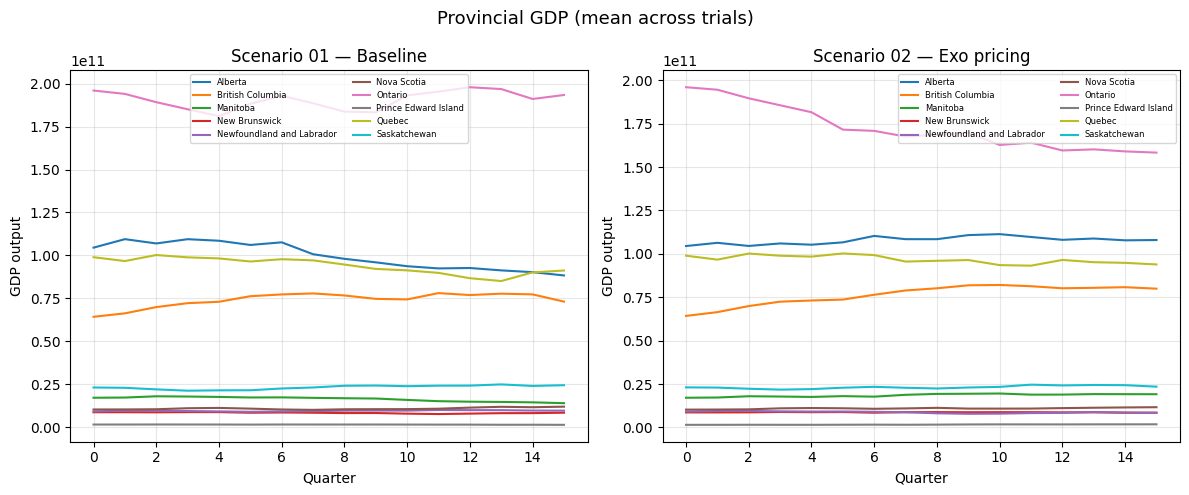

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, sc, res in zip(axes, ["01", "02"], [res_01, res_02]):
    gdp_mean = res["ts_gdp"].mean(axis=0)   # (timesteps, n_provinces)
    x = range(len(ts_time))
    for pi, prov in enumerate(PROVINCES):
        ax.plot(x, gdp_mean[:, pi], label=PROV_LABELS[prov])
    ax.set_title(f"Scenario {sc} — {LABELS[sc]}")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("GDP output")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle("Provincial GDP (mean across trials)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / "provincial_gdp.png", dpi=120)
plt.show()

## 17 — Plot: Emissions by province (annual)

Total greenhouse gas emissions per province, converted from quarterly to annual and averaged across trials. Emissions combine CO2 and CH4 from four sources: firm intermediate inputs, firm capital use, household consumption, and household investment spending. Saved to `output/provincial_emissions.png`.

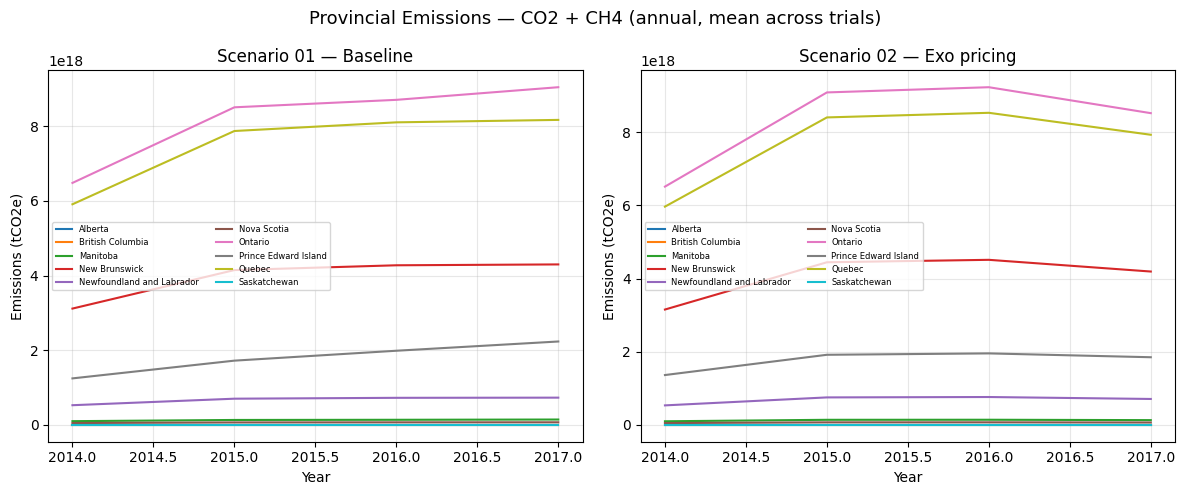

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, sc, res in zip(axes, ["01", "02"], [res_01, res_02]):
    em_qt = res["ts_em_CO2"].sum(axis=-1) + res["ts_em_CH4"].sum(axis=-1)  # (trials, t, prov)
    em_yr = to_annual(em_qt).mean(axis=0)                                    # (years, prov)
    for pi, prov in enumerate(PROVINCES):
        ax.plot(years_axis, em_yr[:, pi], label=PROV_LABELS[prov])
    ax.set_title(f"Scenario {sc} — {LABELS[sc]}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Emissions (tCO2e)")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle("Provincial Emissions — CO2 + CH4 (annual, mean across trials)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / "provincial_emissions.png", dpi=120)
plt.show()

## 18 — Plot: Firm prices by scenario and price difference

`ts_price` holds the economy-wide good price index for each industry at each timestep, recorded from the first province (`CAN_AB`) as a reference. Shape: `(n_trials, timesteps, n_industries)`.

Three panels are produced:
1. **Price levels — Scenario 01 (Baseline)**: endogenous price trajectories per industry.
2. **Price levels — Scenario 02 (Exogenous)**: prices held fixed at 2014 calibrated values.
3. **Price difference (02 − 01)**: positive values mean exogenous prices are above the endogenous baseline; negative values mean the baseline has drifted higher. Only the top 15 industries by mean absolute difference are shown to keep the chart readable.

Saved to `output/firm_prices_comparison.png`.

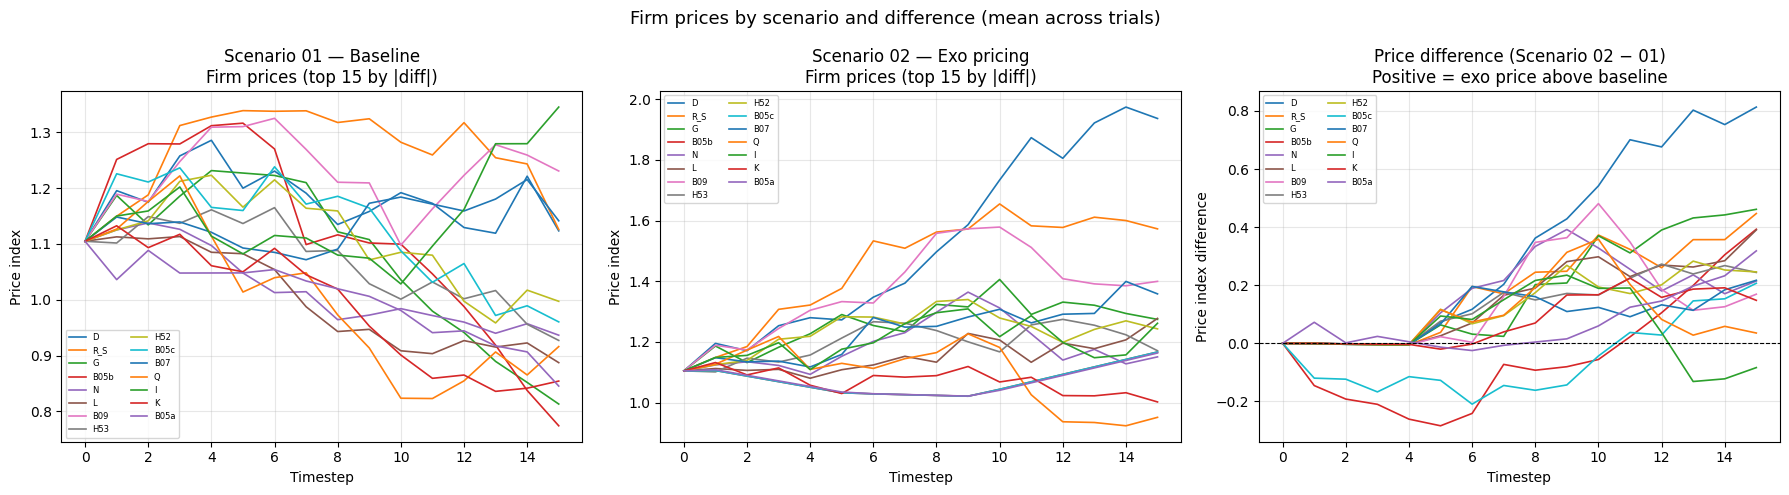


Top 15 industries by mean |price diff|:
   1. D           mean|diff|=0.3429
   2. R_S         mean|diff|=0.1893
   3. G           mean|diff|=0.1841
   4. B05b        mean|diff|=0.1662
   5. N           mean|diff|=0.1645
   6. L           mean|diff|=0.1550
   7. B09         mean|diff|=0.1459
   8. H53         mean|diff|=0.1312
   9. H52         mean|diff|=0.1301
  10. B05c        mean|diff|=0.1204
  11. B07         mean|diff|=0.0988
  12. Q           mean|diff|=0.0981
  13. I           mean|diff|=0.0965
  14. K           mean|diff|=0.0864
  15. B05a        mean|diff|=0.0779


In [88]:
# ts_price shape: (n_trials, timesteps, n_industries)
price_01 = res_01["ts_price"].mean(axis=0)   # (timesteps, n_industries)
price_02 = res_02["ts_price"].mean(axis=0)   # (timesteps, n_industries)
price_diff = price_02 - price_01             # positive = exo price > baseline

# Select top-15 industries by mean absolute difference for the difference panel
mean_abs_diff = np.abs(price_diff).mean(axis=0)   # (n_industries,)
top_idx = np.argsort(mean_abs_diff)[::-1][:15]
ind_labels = list(industries)
x = range(len(ts_time))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: price levels scenario 01 ───────────────────────────────────────
ax = axes[0]
for i in top_idx:
    ax.plot(x, price_01[:, i], label=ind_labels[i], linewidth=1.2)
ax.set_title(f"Scenario 01 — {LABELS['01']}\nFirm prices (top 15 by |diff|)")
ax.set_xlabel("Timestep")
ax.set_ylabel("Price index")
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 2: price levels scenario 02 ───────────────────────────────────────
ax = axes[1]
for i in top_idx:
    ax.plot(x, price_02[:, i], label=ind_labels[i], linewidth=1.2)
ax.set_title(f"Scenario 02 — {LABELS['02']}\nFirm prices (top 15 by |diff|)")
ax.set_xlabel("Timestep")
ax.set_ylabel("Price index")
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 3: price difference (02 − 01) ─────────────────────────────────────
ax = axes[2]
for i in top_idx:
    ax.plot(x, price_diff[:, i], label=ind_labels[i], linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Price difference (Scenario 02 − 01)\nPositive = exo price above baseline")
ax.set_xlabel("Timestep")
ax.set_ylabel("Price index difference")
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle("Firm prices by scenario and difference (mean across trials)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / "firm_prices_comparison.png", dpi=120)
plt.show()

print(f"\nTop 15 industries by mean |price diff|:")
for rank, i in enumerate(top_idx, 1):
    print(f"  {rank:2d}. {ind_labels[i]:<10}  mean|diff|={mean_abs_diff[i]:.4f}")